In [2]:
import sys
print(sys.executable)

d:\Physics\lensing-project\venv\Scripts\python.exe


In [2]:
import numpy as np
from scipy import integrate
from scipy.integrate import quad
from scipy.optimize import brentq
import matplotlib.pyplot as plt

In [3]:
def rho_sfdm(r):
    if r == 0:
        return 1.0
    return np.sin(np.pi * r) / (np.pi * r)

In [4]:
def sigma_sfdm(xi):
    if xi >= 1:
        return 0.0

    zmax = np.sqrt(1 - xi**2)

    integrand = lambda z: rho_sfdm(np.sqrt(xi**2 + z**2))
    result, _ = quad(integrand, 0, zmax)

    return (2) * result

In [5]:
def m_sfdm(xi):
    if xi == 0:
        return 0.0

    integrand = lambda x: x * sigma_sfdm(x)
    result, _ = quad(integrand, 0, xi)

    return 2 * np.pi * result

In [6]:
def beta_theta(theta_star, lambda_bar):
    """
    Ecuación de lente adimensional.
    """
    return theta_star - lambda_bar * m_sfdm(abs(theta_star))/theta_star

In [7]:
theta_vals = np.linspace(-0.99, 0.99, 200)
theta_vals = theta_vals[theta_vals != 0]

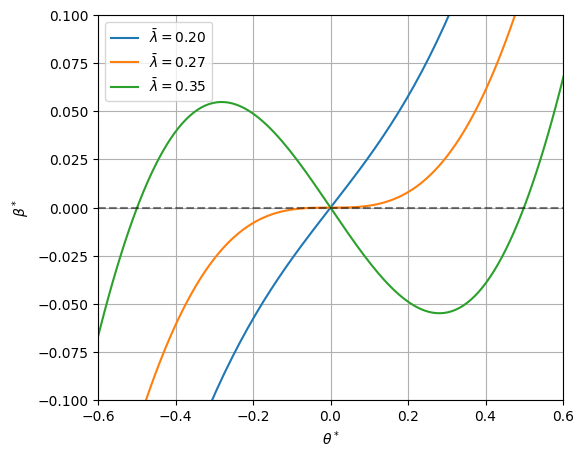

In [8]:
lambda_values = [0.2, 0.27, 0.35]

plt.figure(figsize=(6,5))

for lam in lambda_values:
    beta_vals = [beta_theta(t, lam) for t in theta_vals]
    plt.plot(theta_vals, beta_vals, label=r"$\bar\lambda = %.2f$" % lam)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel(r"$\theta^*$")
plt.ylabel(r"$\beta^*$")
plt.ylim(-0.1, 0.1)
plt.xlim(-0.6,0.6)
plt.legend()
plt.grid()
plt.show()

In [9]:
def rho_burkert(r):
    return 1 / ((1 + r) * (1 + r**2))

In [10]:
def rho_nfw(r):
    if r == 0:
        return 0.0
    return 1 / (r * (1 + r)**2)

In [11]:
def rho_euskera(r):
    A=5.125
    b=1.552
    n=1.118
    m=1.671

    return A * (r**n) * np.exp(-b * r**m)

In [13]:
def sigma_generic(xi, rho_func, rmax_cut=10):
    zmax = np.sqrt(rmax_cut**2 - xi**2)

    integrand = lambda z: rho_func(np.sqrt(xi**2 + z**2))
    result, _ = quad(integrand, 0, zmax)

    return 2 * result

In [14]:
def m_generic(xi, rho_func):
    integrand = lambda x: x * sigma_generic(x, rho_func)
    result, _ = quad(integrand, 0, xi)

    return 2 * np.pi * result

In [23]:
def beta(theta, lambda_bar, m_func):
    return theta - lambda_bar * m_func(abs(theta)) / theta

In [24]:
def einstein_radius(lambda_bar, m_func):
    f = lambda t: beta(t, lambda_bar, m_func)

    try:
        return brentq(f, 1e-4, 5)
    except:
        return None

In [25]:
lambdas = np.linspace(0.05, 0.6, 200)

thetaE_sfdm = []
thetaE_burk = []
thetaE_nfw = []
thetaE_euskera = []

In [26]:
for lam in lambdas:
    thetaE_sfdm.append(einstein_radius(lam, m_sfdm))

    thetaE_burk.append(
        einstein_radius(lam, lambda x: m_generic(x, rho_burkert))
    )

    thetaE_nfw.append(
        einstein_radius(lam, lambda x: m_generic(x, rho_nfw))
    )

    thetaE_euskera.append(
        einstein_radius(lam, lambda x: m_generic(x, rho_euskera))
    )

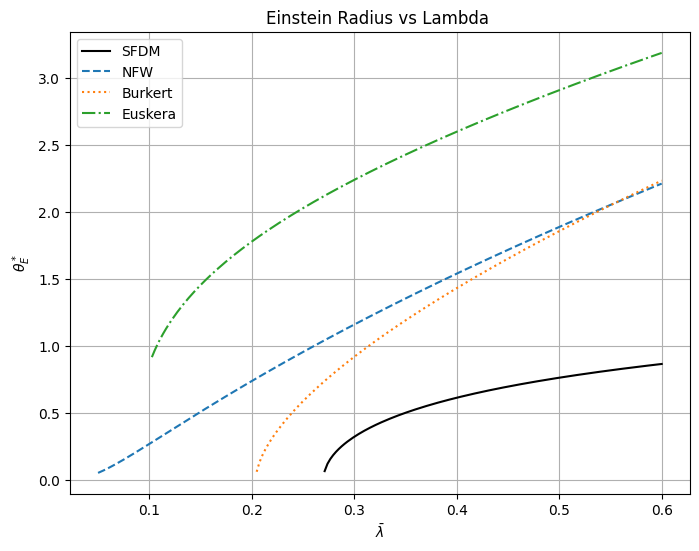

In [27]:
plt.figure(figsize=(8,6))

plt.plot(lambdas, thetaE_sfdm, label='SFDM', color='black')
plt.plot(lambdas, thetaE_nfw, '--', label='NFW')
plt.plot(lambdas, thetaE_burk, ':', label='Burkert')
plt.plot(lambdas, thetaE_euskera, '-.', label='Euskera')

plt.xlabel(r'$\bar{\lambda}$')
plt.ylabel(r'$\theta_E^*$')
plt.legend()
plt.grid()

plt.title('Einstein Radius vs Lambda ')

plt.show()

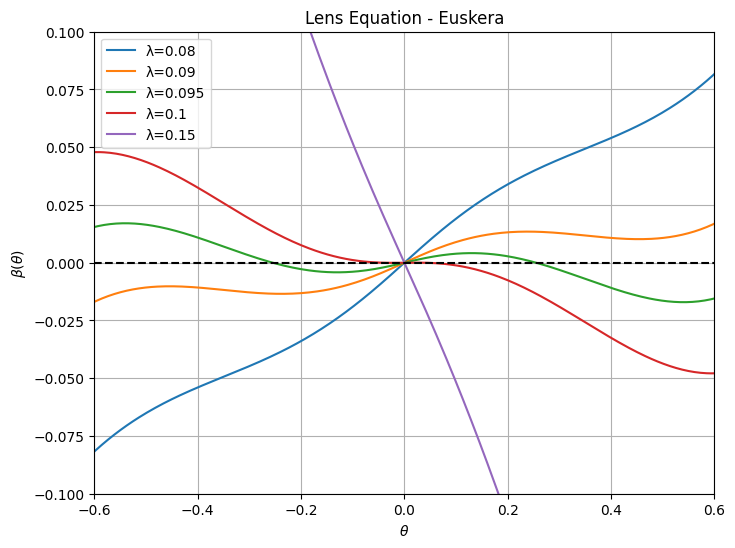

In [49]:
theta_test = np.linspace(-0.99, 0.99, 500)

lambda_test = [0.08, 0.09, 0.095, 0.10, 0.15]

plt.figure(figsize=(8,6))

for lam in lambda_test:

    beta_vals = []

    for t in theta_test:

        val = beta(
            t,
            lam,
            lambda x: m_generic(x, rho_euskera)
        )

        beta_vals.append(val)

    plt.plot(
        theta_test,
        beta_vals,
        label=f'λ={lam}'
    )

plt.axhline(0, color='k', linestyle='--')

plt.xlabel(r'$\theta$')

plt.ylabel(r'$\beta(\theta)$')
plt.ylim(-0.1, 0.1)
plt.xlim(-0.6,0.6)

plt.title('Lens Equation - Euskera')

plt.legend()

plt.grid()

plt.show()

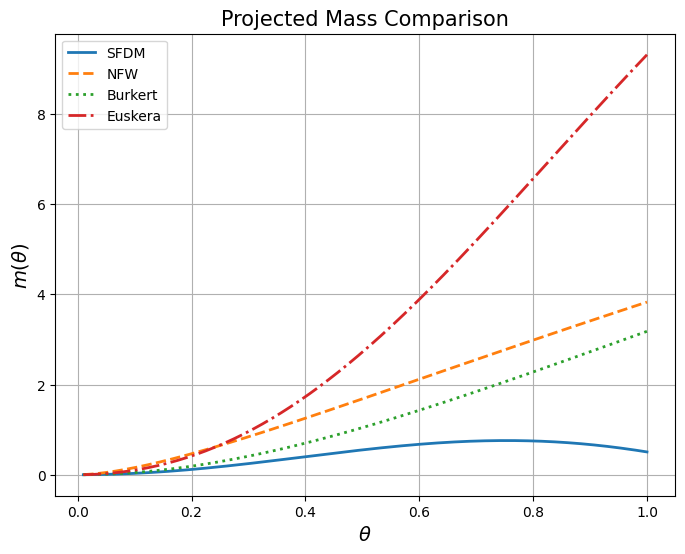

In [50]:
# ============================================================
# COMPARACIÓN DE MASAS PROYECTADAS
# m(theta)
# ============================================================

# Rango radial
theta_vals = np.linspace(0.01, 1.0, 300)

# ------------------------------------------------------------
# Calcular masas proyectadas
# ------------------------------------------------------------

m_sfdm_vals = []
m_nfw_vals = []
m_burkert_vals = []
m_euskera_vals = []

for t in theta_vals:

    # SFDM
    m_sfdm_vals.append(
        m_generic(t, rho_sfdm)
    )

    # NFW
    m_nfw_vals.append(
        m_generic(t, rho_nfw)
    )

    # Burkert
    m_burkert_vals.append(
        m_generic(t, rho_burkert)
    )

    # Euskera
    m_euskera_vals.append(
        m_generic(t, rho_euskera)
    )

# ============================================================
# GRAFICAR
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    theta_vals,
    m_sfdm_vals,
    label='SFDM',
    linewidth=2
)

plt.plot(
    theta_vals,
    m_nfw_vals,
    label='NFW',
    linestyle='--',
    linewidth=2
)

plt.plot(
    theta_vals,
    m_burkert_vals,
    label='Burkert',
    linestyle=':',
    linewidth=2
)

plt.plot(
    theta_vals,
    m_euskera_vals,
    label='Euskera',
    linestyle='-.',
    linewidth=2
)

# ------------------------------------------------------------

plt.xlabel(r'$\theta$', fontsize=14)

plt.ylabel(r'$m(\theta)$', fontsize=14)

plt.title('Projected Mass Comparison', fontsize=15)

plt.legend()

plt.grid()

plt.show()